Veri seti boyutu: (10999, 12)
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0               

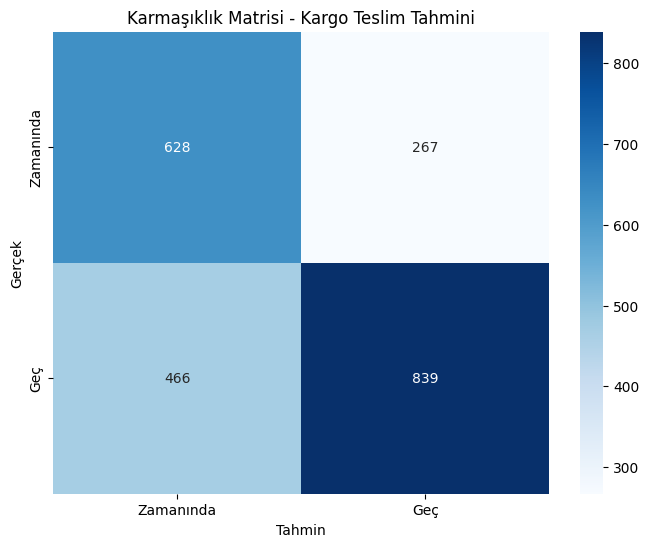


✅ Model kaydedildi!


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi yükle
df = pd.read_csv('Train.csv')
print("Veri seti boyutu:", df.shape)
print(df.head())

# ID sütununu at
df = df.drop('ID', axis=1)

# Kategorik sütunları sayıya çevir ve encoder'ları sakla
encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Hedef: Reached.on.Time_Y.N (1 = zamanında gelmedi/geç, 0 = zamanında geldi)
X = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

# Eğitim/test ayır
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli eğit
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Sonuçlar
y_pred = model.predict(X_test)
print("\n=== SONUÇLAR ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix grafiği
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Zamanında', 'Geç'],
            yticklabels=['Zamanında', 'Geç'])
plt.title('Karmaşıklık Matrisi - Kargo Teslim Tahmini')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Modeli ve encoder'ları kaydet
joblib.dump(model, 'model.pkl')
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(list(X.columns), 'columns.pkl')
print("\n✅ Model kaydedildi!")